# Pertemuan 5 - Data Science

**Nama:** Krisno Hasmilu Hutabarat  
**NIM:** 240401010102  
**Kelas:** IF401  
**Mata Kuliah:** Data Science

## 1. Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset Tips. Jika dataset bawaan Seaborn tidak dapat diakses,
# digunakan data cadangan sederhana agar notebook tetap bisa dijalankan.
try:
    df = sns.load_dataset('tips')
    print('Dataset tips berhasil dimuat dari Seaborn.')
except Exception as e:
    print('Dataset Seaborn gagal dimuat, menggunakan data cadangan.')
    print('Alasan:', e)
    df = pd.DataFrame({
        'total_bill': [16.99, 10.34, 21.01, 23.68, 24.59, 25.29, 8.77, 26.88, 15.04, 14.78, 10.27, 35.26],
        'tip': [1.01, 1.66, 3.50, 3.31, 3.61, 4.71, 2.00, 3.12, 1.96, 3.23, 1.71, 5.00],
        'sex': ['Female', 'Male', 'Male', 'Male', 'Female', 'Male', 'Male', 'Male', 'Male', 'Male', 'Male', 'Female'],
        'smoker': ['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'],
        'day': ['Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Sun', 'Thur', 'Thur', 'Fri', 'Sat'],
        'time': ['Dinner', 'Dinner', 'Dinner', 'Dinner', 'Dinner', 'Dinner', 'Dinner', 'Dinner', 'Lunch', 'Lunch', 'Dinner', 'Dinner'],
        'size': [2, 3, 3, 2, 4, 4, 2, 4, 2, 2, 2, 4]
    })

# Pastikan urutan kategori hari rapi
df['day'] = pd.Categorical(df['day'], categories=['Thur', 'Fri', 'Sat', 'Sun'], ordered=True)
df.head()

Dataset tips berhasil dimuat dari Seaborn.


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Grafik 1 — Bar Chart: Rata-rata Total Tagihan per Hari

**What?** Grafik ini menampilkan rata-rata total tagihan (USD) per hari dalam seminggu dari 244 observasi. Nilai tertinggi ada di hari Jumat ($22.81) dan terendah di hari Minggu ($21.41).

**So what?** Jumat memiliki tagihan rata-rata tertinggi meskipun jumlah transaksinya paling sedikit, mengindikasikan pelanggan Jumat cenderung memesan lebih banyak per kunjungan — kemungkinan karena makan malam bersama rekan kerja di akhir pekan kerja.

**Now what?** Perlu dieksplorasi apakah transaksi Jumat didominasi oleh kelompok besar atau tamu individual. Manajemen restoran bisa mempertimbangkan promo spesial hari Kamis untuk mendorong nilai transaksi yang masih di bawah rata-rata.

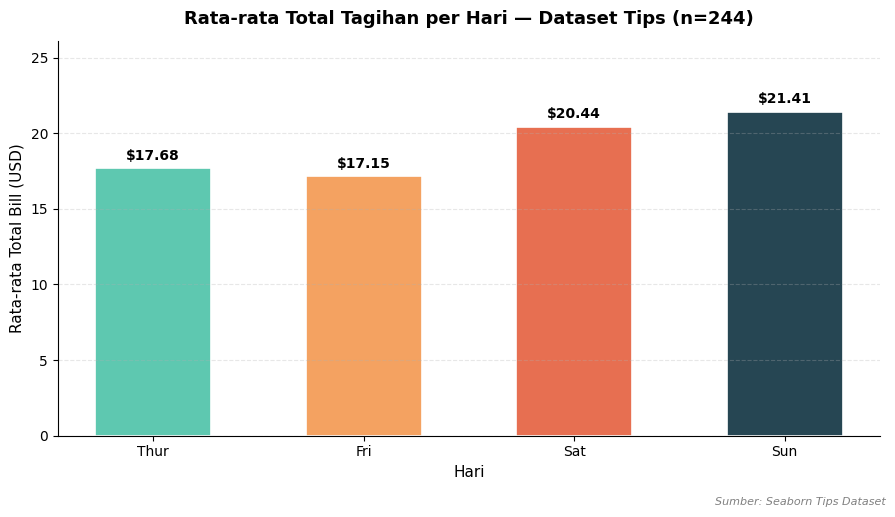

In [2]:
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(avg_by_day.index, avg_by_day.values,
              color=['#5EC8B0', '#F4A261', '#E76F51', '#264653'],
              edgecolor='white', linewidth=1.2, width=0.55)
ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=10, fontweight='bold')

ax.set_title('Rata-rata Total Tagihan per Hari — Dataset Tips (n=244)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hari', fontsize=11)
ax.set_ylabel('Rata-rata Total Bill (USD)', fontsize=11)
ax.set_ylim(0, avg_by_day.max() * 1.22)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=0)

fig.text(0.99, -0.02, 'Sumber: Seaborn Tips Dataset', ha='right', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('grafik1_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Grafik 2 — Histogram + KDE: Distribusi Tagihan per Waktu Makan

**What?** Grafik menampilkan distribusi frekuensi total tagihan (USD) yang dibedakan berdasarkan waktu makan (Lunch vs Dinner) dengan kurva KDE overlay. Rentang nilai berkisar antara $3.07 hingga $50.81.

**So what?** Kedua distribusi condong ke kanan (right-skewed), artinya mayoritas transaksi bernilai kecil namun ada ekor panjang ke arah tagihan besar. Dinner memiliki ekor distribusi yang lebih panjang dibanding Lunch, menunjukkan transaksi bernilai besar ($40+) lebih sering terjadi di malam hari.

**Now what?** Restoran sebaiknya menyiapkan lebih banyak staf dan bahan baku premium saat Dinner untuk mengakomodasi potensi transaksi besar. Analisis lanjutan perlu melihat apakah tagihan besar Dinner berkorelasi dengan ukuran kelompok tamu yang lebih besar.

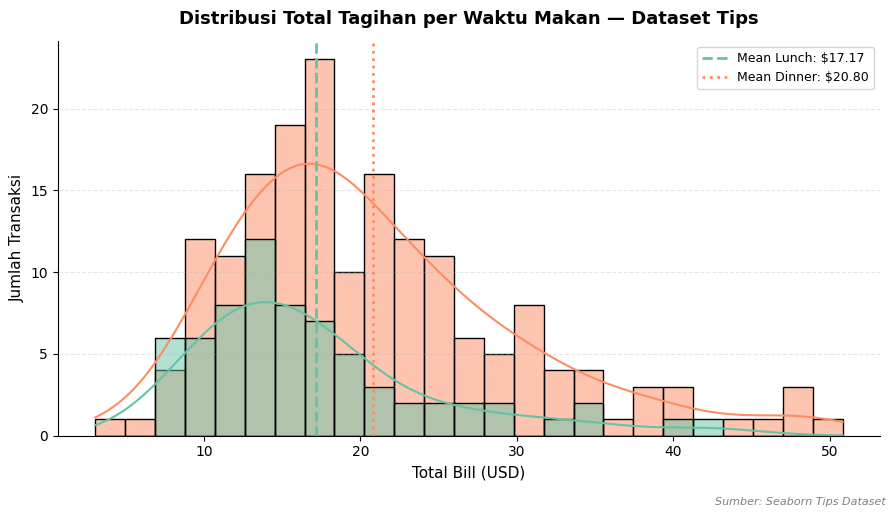

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.5,
             bins=25, ax=ax)

ax.set_title('Distribusi Total Tagihan per Waktu Makan — Dataset Tips', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Bill (USD)', fontsize=11)
ax.set_ylabel('Jumlah Transaksi', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Tambahkan garis mean
for time, color, ls in zip(['Lunch', 'Dinner'], ['#66C2A5', '#FC8D62'], ['--', ':']):
    mean_val = df[df['time'] == time]['total_bill'].mean()
    ax.axvline(mean_val, color=color, linestyle=ls, linewidth=2,
               label=f'Mean {time}: ${mean_val:.2f}')

ax.legend(fontsize=9)
fig.text(0.99, -0.02, 'Sumber: Seaborn Tips Dataset', ha='right', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('grafik2_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Grafik 3 — Boxplot: Distribusi Tagihan per Hari & Gender

**What?** Boxplot membandingkan sebaran total tagihan antara pelanggan pria (Male) dan wanita (Female) untuk setiap hari dalam seminggu. Garis tengah kotak menunjukkan nilai median, kotak mencakup Q1–Q3 (IQR), dan titik di luar whisker adalah outlier.

**So what?** Pelanggan pria secara konsisten memiliki median tagihan yang lebih tinggi di hampir semua hari. Outlier dengan nilai tagihan ekstrem (>$40) hampir seluruhnya berasal dari kelompok pria, mengindikasikan bahwa transaksi besar lebih sering dilakukan oleh pria.

**Now what?** Perlu analisis lebih lanjut untuk mengontrol variabel party size — perbedaan gender ini bisa jadi hanya mencerminkan fakta bahwa pria lebih sering datang dalam kelompok lebih besar. Jika dikontrol ukuran kelompok dan perbedaan tetap signifikan, ini bisa menjadi insight penting untuk strategi marketing.

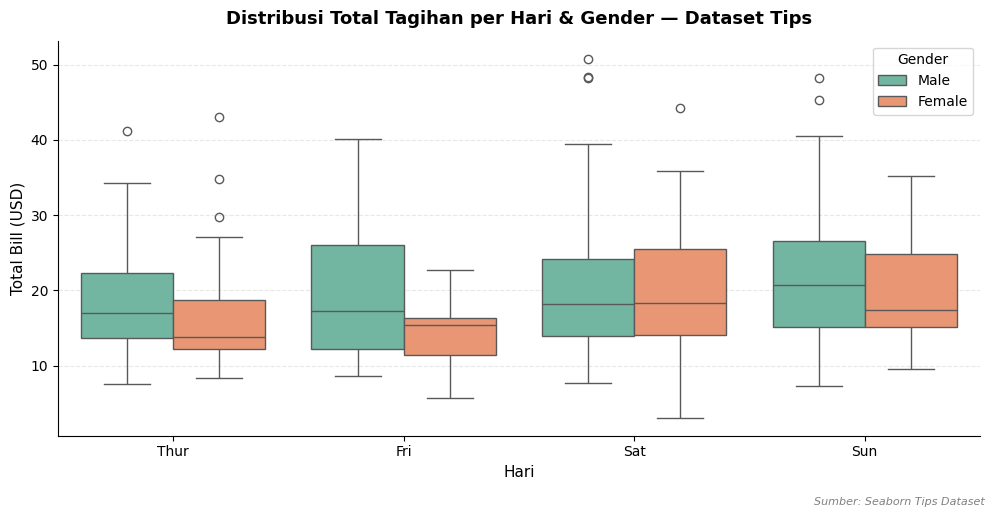

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set2',
            order=day_order, ax=ax)

ax.set_title('Distribusi Total Tagihan per Hari & Gender — Dataset Tips', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Hari', fontsize=11)
ax.set_ylabel('Total Bill (USD)', fontsize=11)
ax.legend(title='Gender', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.text(0.99, -0.02, 'Sumber: Seaborn Tips Dataset', ha='right', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('grafik3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Grafik 4 — Scatter Plot: Hubungan Total Tagihan & Tip

**What?** Scatter plot menampilkan hubungan antara total tagihan (sumbu X, USD) dan jumlah tip (sumbu Y, USD) untuk 244 transaksi, dibedakan berdasarkan waktu makan (Lunch/Dinner). Ukuran titik merepresentasikan jumlah tamu (party size). Garis abu-abu putus-putus adalah garis regresi linear keseluruhan.

**So what?** Terdapat korelasi positif yang sangat kuat (r ≈ 0.68) antara total tagihan dan tip — semakin besar tagihan, semakin besar tip yang diberikan. Hubungan ini konsisten untuk Lunch maupun Dinner. Beberapa transaksi Dinner dengan tamu banyak (titik besar) memberikan tip yang relatif rendah dibanding nilai tagihannya.

**Now what?** Karena tip sangat diprediksi oleh nilai tagihan, strategi upselling (mendorong pelanggan memesan item tambahan) secara langsung meningkatkan pendapatan staf dari tip. Perlu juga dieksplorasi apakah pelanggan dengan party size besar memberikan tip secara proporsional lebih kecil — jika ya, staf perlu strategi berbeda saat melayani meja besar.

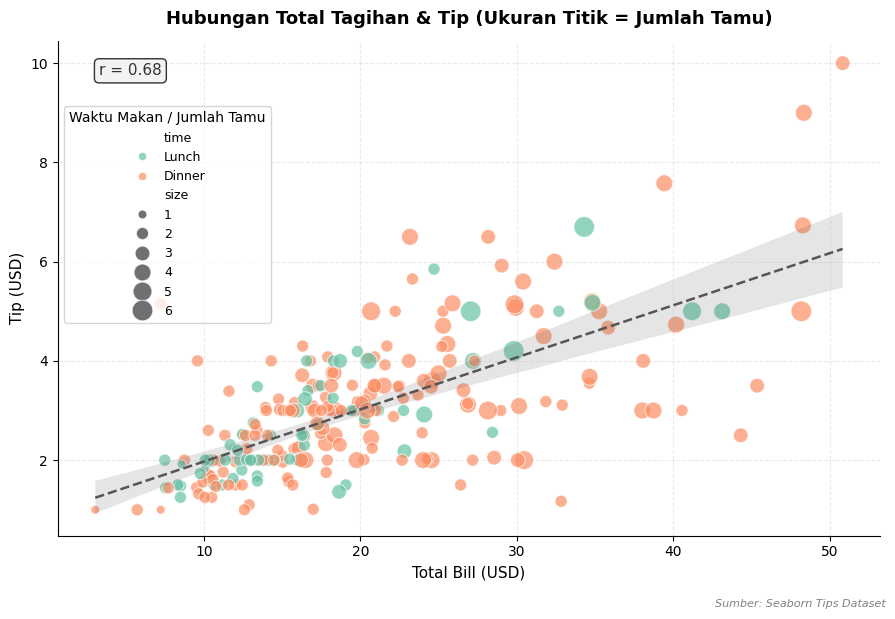

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(40, 220), palette='Set2',
                alpha=0.7, ax=ax)

# Garis regresi
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='#555555',
            line_kws={'linestyle': '--', 'linewidth': 1.8},
            ax=ax)

# Korelasi
corr = df['total_bill'].corr(df['tip'])
ax.text(0.05, 0.93, f'r = {corr:.2f}', transform=ax.transAxes,
        fontsize=11, color='#333', bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))

ax.set_title('Hubungan Total Tagihan & Tip (Ukuran Titik = Jumlah Tamu)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Bill (USD)', fontsize=11)
ax.set_ylabel('Tip (USD)', fontsize=11)
ax.legend(title='Waktu Makan / Jumlah Tamu', fontsize=9, loc='upper left', bbox_to_anchor=(0.0, 0.88))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.25, linestyle='--')

fig.text(0.99, -0.02, 'Sumber: Seaborn Tips Dataset', ha='right', fontsize=8, color='gray', style='italic')
plt.tight_layout()
plt.savefig('grafik4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Dashboard Lengkap (Semua Grafik dalam Satu Figure)

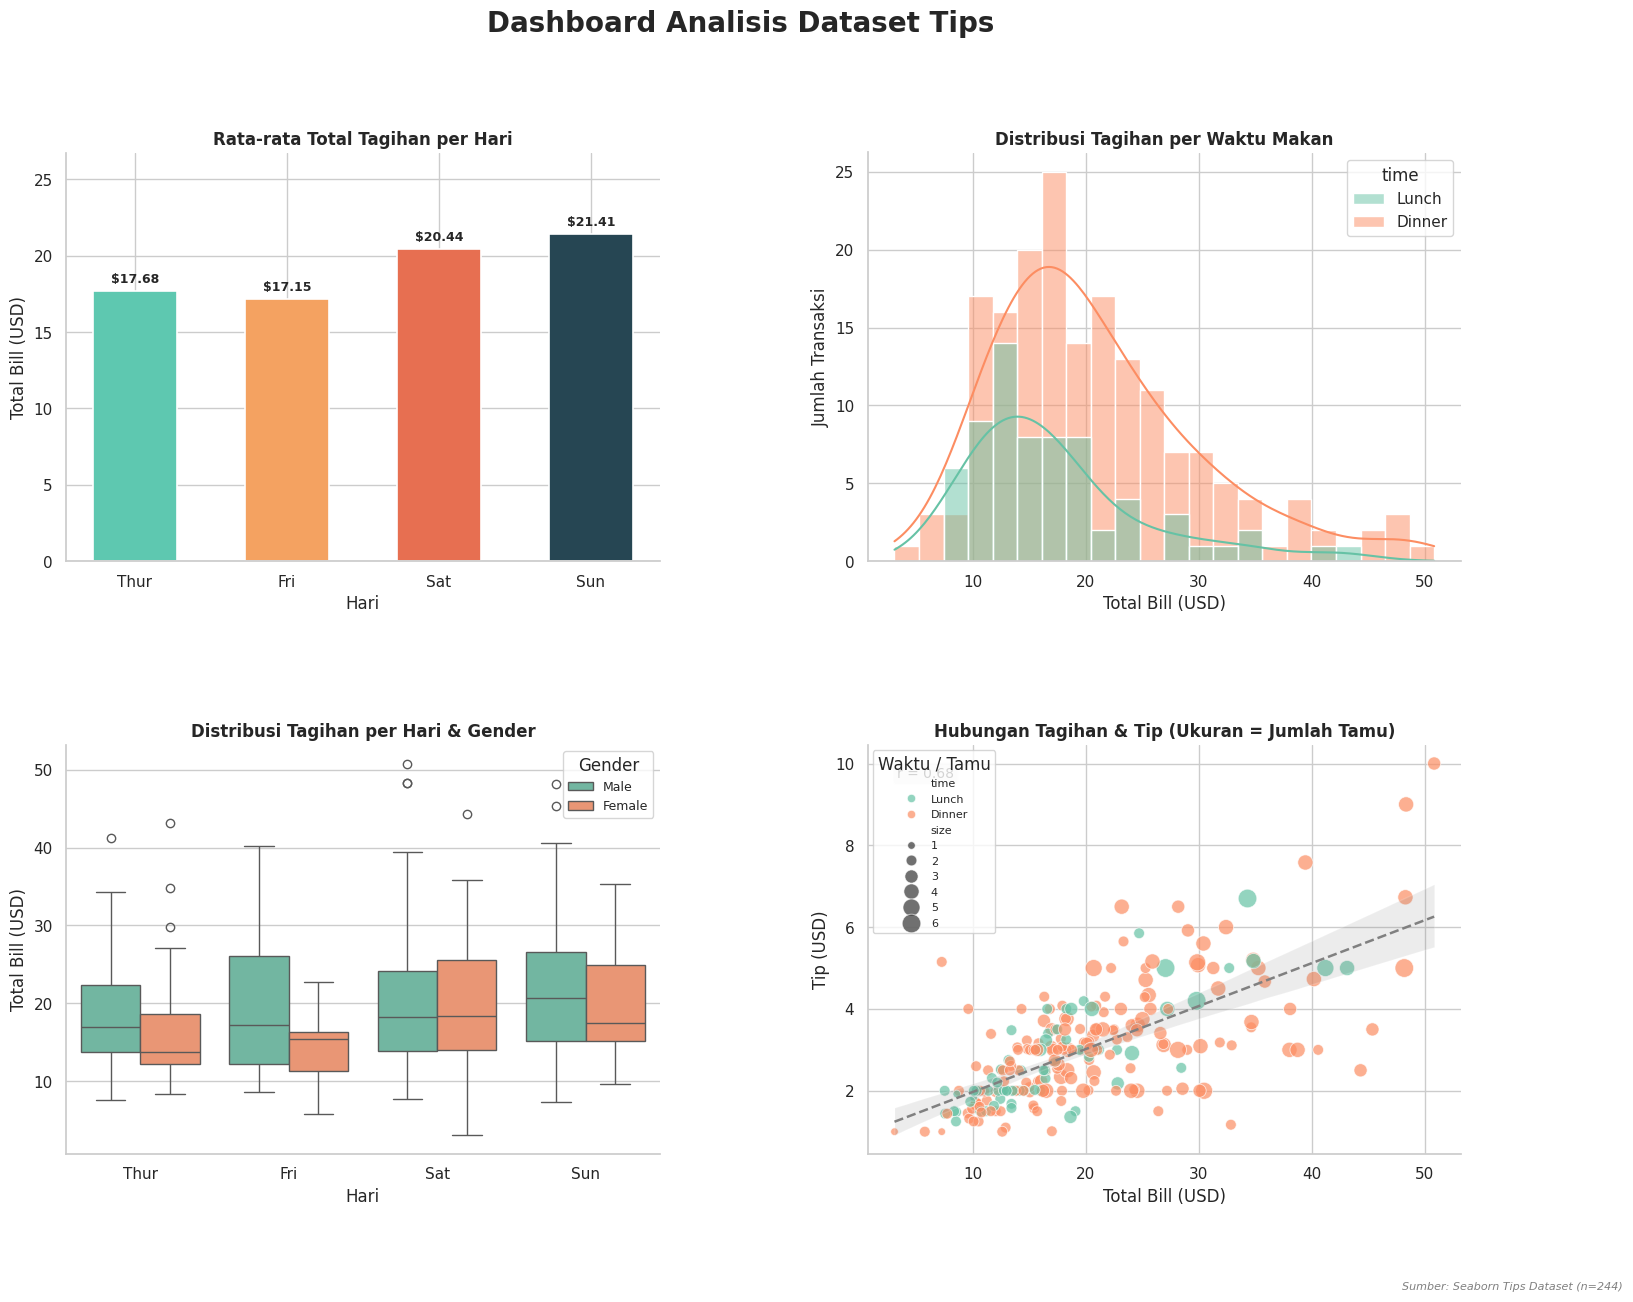

Dashboard tersimpan sebagai dashboard_tips.png


In [6]:
sns.set_theme(style='whitegrid')

fig = plt.figure(figsize=(18, 13))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=20, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1: Bar Chart
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean().reindex(day_order)
bars = ax1.bar(avg_by_day.index, avg_by_day.values,
               color=['#5EC8B0','#F4A261','#E76F51','#264653'],
               edgecolor='white', linewidth=1.2, width=0.55)
ax1.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9, fontweight='bold')
ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.set_ylim(0, avg_by_day.max() * 1.25)
ax1.spines[['top','right']].set_visible(False)

# Grafik 2: Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.5, bins=22, ax=ax2)
ax2.set_title('Distribusi Tagihan per Waktu Makan', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Bill (USD)'); ax2.set_ylabel('Jumlah Transaksi')
ax2.spines[['top','right']].set_visible(False)

# Grafik 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set2', order=day_order, ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hari'); ax3.set_ylabel('Total Bill (USD)')
ax3.legend(title='Gender', fontsize=9)
ax3.spines[['top','right']].set_visible(False)

# Grafik 4: Scatter + Regresi
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle':'--', 'linewidth':1.8}, ax=ax4)
corr = df['total_bill'].corr(df['tip'])
ax4.text(0.05, 0.92, f'r = {corr:.2f}', transform=ax4.transAxes, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0', alpha=0.8))
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Bill (USD)'); ax4.set_ylabel('Tip (USD)')
ax4.legend(title='Waktu / Tamu', fontsize=8)
ax4.spines[['top','right']].set_visible(False)

fig.text(0.99, 0.005, 'Sumber: Seaborn Tips Dataset (n=244)', ha='right',
         fontsize=8, color='gray', style='italic')

plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

## Referensi

- Knaflic, C. N. (2015). *Storytelling with Data*. Wiley.
- Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software*, 6(60), 3021.
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.

## Kesimpulan

Pada pertemuan ini, saya mempelajari cara membuat visualisasi data dan dashboard statis menggunakan dataset Tips. Beberapa visualisasi yang digunakan antara lain bar chart, histogram, boxplot, scatter plot, dan dashboard gabungan dalam satu figure.

Temuan utama dari praktikum ini adalah visualisasi dapat membantu menjelaskan pola data, seperti rata-rata total tagihan per hari, distribusi tagihan, perbedaan tagihan berdasarkan kategori, dan hubungan antara total tagihan dengan tip. Keterbatasannya adalah dashboard yang dibuat masih bersifat statis, sehingga belum memiliki interaksi seperti filter atau tampilan web.